# Pipeline vs Baseline Experiment

In [12]:
import sys
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

BASELINE_DIR = REPO_ROOT / "baseline"
if str(BASELINE_DIR) not in sys.path:
    sys.path.insert(0, str(BASELINE_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = REPO_ROOT / "database" / "training_data.json"
EXPERIMENT_DIR = REPO_ROOT / "experiments"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"CUDA available: {torch.cuda.is_available()}")

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json
CUDA available: True


In [13]:
import logging
from datetime import datetime

from logger import configure_logging

TRACE_LOG_PATH = EXPERIMENT_DIR / f"experimentation_pipeline_vs_baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
configure_logging(
    level="INFO",
    log_file=str(TRACE_LOG_PATH),
    enable_console=True,
    enable_file=True,
)

exp_logger = logging.getLogger("experimentation_pipeline_vs_baseline")
exp_logger.info("Trace logging initialized")
print(f"Trace log file: {TRACE_LOG_PATH}")

2026-03-22 22:59:01,351 - experimentation_pipeline_vs_baseline - INFO - Trace logging initialized
Trace log file: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/experimentation_pipeline_vs_baseline_20260322_225901.log


In [14]:
TARGET = {
    "dbaasp_id": "DBAASPS_373",
    "sequence": "KLFKRWKHLFR",
    "length": 11,
    "smiles": "CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O",
    "ph": None,
    "molecular_weight": 1558.9480000000003,
    "logp": -0.992100000000006,
    "net_charge": 5.0,
    "isoelectric_point": 12.18,
    "hydrophobicity": 1.05,
    "cathionicity": 6,
    "target_groups": ["Gram+"],
    "complexity": "Monomer"
}

SHARED_MAX_LEN = 14
SHARED_BATCH_SIZE = 32
SHARED_EPOCHS = 100
SHARED_LATENT_DIM = 32

# Tuned pipeline hyperparameters (from pipeline_experimentations reference setup).
PIPELINE_LATENT_DIM = 64
PIPELINE_HIDDEN_DIM = 512
PIPELINE_EPOCHS = 120
PIPELINE_BATCH_SIZE = 64
PIPELINE_LR = 0.05
PIPELINE_KL_ANNEAL_EPOCHS = 40

NB_ITERATIONS = 50
NB_PEPTIDES = 300
TOP_K = 10
BASELINE_NUM_SAMPLES = 10

print(TARGET)
print(
    f"Pipeline tuned config -> latent={PIPELINE_LATENT_DIM}, hidden={PIPELINE_HIDDEN_DIM}, "
    f"epochs={PIPELINE_EPOCHS}, batch={PIPELINE_BATCH_SIZE}, lr={PIPELINE_LR}, kl_anneal={PIPELINE_KL_ANNEAL_EPOCHS}"
)

{'dbaasp_id': 'DBAASPS_373', 'sequence': 'KLFKRWKHLFR', 'length': 11, 'smiles': 'CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O', 'ph': None, 'molecular_weight': 1558.9480000000003, 'logp': -0.992100000000006, 'net_charge': 5.0, 'isoelectric_point': 12.18, 'hydrophobicity': 1.05, 'cathionicity': 6, 'target_groups': ['Gram+'], 'complexity': 'Monomer'}
Pipeline tuned config -> latent=64, hidden=512, epochs=120, batch=64, lr=0.05, kl_anneal=40


In [15]:
from training import train_model
from inference import generate_peptides

baseline_model_path = EXPERIMENT_DIR / "baseline_cvae_model.pth"
baseline_scaler_path = EXPERIMENT_DIR / "baseline_scaler.pkl"

baseline_model, _ = train_model(
    dataset_file=str(DATA_PATH),
    scaler_path=str(baseline_scaler_path),
    batch_size=SHARED_BATCH_SIZE,
    max_len=SHARED_MAX_LEN,
    epochs=SHARED_EPOCHS,
    latent_dim=SHARED_LATENT_DIM,
    model_path=str(baseline_model_path),
)

with open(baseline_scaler_path, "rb") as f:
    baseline_scaler = pickle.load(f)

baseline_target = [
    TARGET["length"],
    7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    TARGET["molecular_weight"],
    TARGET["logp"],
    TARGET["net_charge"],
    TARGET["isoelectric_point"],
    TARGET["hydrophobicity"],
    TARGET["cathionicity"],
]

baseline_sequences = generate_peptides(
    model=baseline_model,
    scaler=baseline_scaler,
    num_samples=BASELINE_NUM_SAMPLES,
    properties=baseline_target,
    temperature=0.9,
    top_k=5,
)

Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scaler.pkl
Epoch [1/100] | Beta: 0.00 | Train Loss: 21.4799 | Train Recon: 21.4799 | Train KL: 66.7116 | Val Loss: 18.3806 | Val Recon: 18.3806 | Val KL: 108.8033
Epoch [5/100] | Beta: 0.08 | Train Loss: 13.9652 | Train Recon: 12.3938 | Train KL: 19.6430 | Val Loss: 13.4713 | Val Recon: 11.9304 | Val KL: 19.2605
Epoch [10/100] | Beta: 0.18 | Train Loss: 11.5829 | Train Recon: 8.9925 | Train KL: 14.3912 | Val Loss: 11.8423 | Val Recon: 9.3397 | Val KL: 13.9030
Epoch [15/100] | Beta: 0.28 | Train Loss: 10.7538 | Train Recon: 7.5165 | Train KL: 11.5619 | Val Loss: 11.6593 | Val Recon: 8.5647 | Val KL: 11.0521
Epoch [20/100] | Beta: 0.38 | Train Loss: 10.7060 | Train Recon: 7.1009 | Train KL: 9.4871 | Val Loss: 11.9754 | Val Recon: 8.4172 | Val KL: 9.3638
Epoch [25/100] | Beta: 0.48 | Train Loss: 10.7938 | Train Recon: 6.9396 | Train KL: 8.0294 | Val Loss: 12.0935 | Val Recon

In [16]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21


def encode_one_hot_with_pad(sequences, max_len):
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe, model):
    cond = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        "sequence",
        "length",
        "ph",
        "molecular_weight",
        "logp",
        "net_charge",
        "isoelectric_point",
        "hydrophobicity",
        "cathionicity",
    ],
    fillna_defaults={
        "length": 10,
        "ph": 7.0,
        "molecular_weight": 1500.0,
        "logp": 0.0,
        "net_charge": 0.0,
        "isoelectric_point": 7.0,
        "hydrophobicity": 0.0,
        "cathionicity": 0.0,
    },
    normalize_sequence=True,
    sequence_column="sequence",
    keep_standard_amino_acids_only=True,
)

pipeline_df = loader.get_data().copy()

pipeline_cvae = CVAEGenerator(
    max_len=SHARED_MAX_LEN,
    latent_dim=PIPELINE_LATENT_DIM,
    hidden_dim=PIPELINE_HIDDEN_DIM,
    condition_dim=32,
)

pipeline_model_path = EXPERIMENT_DIR / (
    f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
)

x = encode_one_hot_with_pad(pipeline_df["sequence"].tolist(), max_len=SHARED_MAX_LEN)
conditions = build_condition_tensor(pipeline_df, pipeline_cvae)
lengths = torch.tensor(pipeline_df["length"].astype(int).values, dtype=torch.long)

x = x.to(pipeline_cvae.device)
conditions = conditions.to(pipeline_cvae.device)
lengths = lengths.to(pipeline_cvae.device)

if pipeline_model_path.exists():
    pipeline_cvae.load_model(str(pipeline_model_path))
else:
    pipeline_cvae.train_model(
        data=x,
        conditions=conditions,
        lengths=lengths,
        epochs=PIPELINE_EPOCHS,
        batch_size=PIPELINE_BATCH_SIZE,
        lr=PIPELINE_LR,
        kl_anneal_epochs=PIPELINE_KL_ANNEAL_EPOCHS,
    )
    pipeline_cvae.save_model(str(pipeline_model_path))

print(f"Using pipeline model path: {pipeline_model_path.name}")

2026-03-22 22:59:42,570 - peptide_pipeline.dataloader - INFO - DataLoader initialized.
2026-03-22 22:59:42,598 - peptide_pipeline.dataloader - INFO - Data loaded successfully from /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json. Total records: 4410
2026-03-22 22:59:42,599 - peptide_pipeline.dataloader - INFO - Data retrieval successful.
Using pipeline model path: pipeline_cvae_model_lat64_hid512_ep120_bs64.pth


In [17]:
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2
from peptide_pipeline.biologist.base import BaseBiologist


class FallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        scores = []
        ref_set = set(self.reference)
        for p in peptides:
            common = len(ref_set.intersection(set(p)))
            scores.append(common / max(len(set(self.reference)), 1))
        return scores


chemist_config = ChemistConfig(
    ph=7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    length=RangeTarget(min=8.0, max=14.0, target=float(TARGET["length"]), weight=1.0),
    molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(TARGET["molecular_weight"]), weight=1.0),
    logp=RangeTarget(min=-3.0, max=3.0, target=float(TARGET["logp"]), weight=1.0),
    net_charge=RangeTarget(min=2.0, max=8.0, target=float(TARGET["net_charge"]), weight=1.0),
    isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(TARGET["isoelectric_point"]), weight=1.0),
    hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(TARGET["hydrophobicity"]), weight=1.0),
)

chemist = ChemistAgent(config=chemist_config)

try:
    biologist = ESMBiologistGlobalL2(
        reference_peptide=TARGET["sequence"],
        batch_size=16,
        score_temperature=50.0,
    )
except Exception as e:
    print(f"Falling back to lightweight biologist: {e}")
    biologist = FallbackBiologist(reference_peptide=TARGET["sequence"])

orchestrator = Orchestrator(generator=pipeline_cvae, chemist=chemist, biologist=biologist)
pipeline_results = orchestrator.run(
    nb_iterations=NB_ITERATIONS,
    nb_peptides=NB_PEPTIDES,
    top_k=TOP_K,
    exploration_rate=0.15,
    initial_peptide=TARGET["sequence"],
    final_target={
        "length": TARGET["length"],
        "molecular_weight": TARGET["molecular_weight"],
        "logp": TARGET["logp"],
        "net_charge": TARGET["net_charge"],
        "isoelectric_point": TARGET["isoelectric_point"],
        "hydrophobicity": TARGET["hydrophobicity"],
        "cathionicity": TARGET["cathionicity"],
    },
)

2026-03-22 22:59:43,113 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 22:59:43,128 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-22 22:59:43,242 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 22:59:43,259 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-22 22:59:43,373 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-22 22:5

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1463.21it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-03-22 22:59:43,842 - peptide_pipeline.orchestrator - INFO - Pipeline start: 50 iterations, 300 peptides/iteration, exploration_rate=0.15, top_k=10
2026-03-22 22:59:43,843 - peptide_pipeline.orchestrator - INFO - Iteration 1: initial_peptide is provided ('KLFKRWKHLFR') but generation is driven by final_target constraints only.
2026-03-22 22:59:44,228 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=300, in_limits=1, off_limits=299, best_combined=0.8315, global_unique=1


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-22 22:59:44,599 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=300, in_limits=3, off_limits=297, best_combined=0.8222, global_unique=4
2026-03-22 22:59:44,970 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploration_random, generated=300, in_limits=7, off_limits=293, best_combined=0.8549, global_unique=11
2026-03-22 22:59:45,340 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.8293, global_unique=15
2026-03-22 22:59:45,709 - peptide_pipeline.orchestrator - INFO - Iteration 5: mode=exploitation_top, generated=300, in_limits=7, off_limits=293, best_combined=0.8124, global_unique=22
2026-03-22 22:59:46,071 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.7893, global_unique=26
2026-03-22 22:59:46,430 - peptide_pipeline.orchestrator - INFO - Iteration 7: m

In [18]:
import csv

pipeline_display = []
for row in pipeline_results:
    item = {
        "sequence": row.get("peptide", ""),
        "score": row.get("score"),
        "chemist_score": row.get("chemist_score"),
        "biologist_score": row.get("biologist_score"),
        "length": row.get("properties", {}).get("length"),
        "molecular_weight": row.get("properties", {}).get("molecular_weight"),
        "net_charge": row.get("properties", {}).get("net_charge"),
        "isoelectric_point": row.get("properties", {}).get("isoelectric_point"),
        "hydrophobicity": row.get("properties", {}).get("hydrophobicity"),
        "logp": row.get("properties", {}).get("logp"),
        "in_limits": row.get("in_limits", False),
    }
    pipeline_display.append(item)

pipeline_display_df = pd.DataFrame(pipeline_display)
if not pipeline_display_df.empty:
    pipeline_display_df = pipeline_display_df.sort_values(by=["in_limits", "score"], ascending=[False, False]).reset_index(drop=True)
    for col in ["score", "chemist_score", "biologist_score", "molecular_weight", "net_charge", "isoelectric_point", "hydrophobicity", "logp"]:
        if col in pipeline_display_df.columns:
            pipeline_display_df[col] = pipeline_display_df[col].astype(float).round(3)

baseline_clean = [seq for seq in baseline_sequences if isinstance(seq, str) and seq]
baseline_df = pd.DataFrame({
    "rank": list(range(1, len(baseline_clean) + 1)),
    "sequence": baseline_clean,
})

target_df = pd.DataFrame([TARGET])
combined_csv_path = EXPERIMENT_DIR / "pipeline_vs_baseline_results.csv"

target_cols = list(target_df.columns)
pipeline_cols = [
    "sequence",
    "score",
    "chemist_score",
    "biologist_score",
    "in_limits",
    "length",
    "molecular_weight",
    "net_charge",
    "isoelectric_point",
    "hydrophobicity",
    "logp",
]
baseline_cols = ["rank", "sequence"]

with open(combined_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["TARGET"])
    writer.writerow(target_cols)
    writer.writerow([TARGET.get(col, "") for col in target_cols])
    writer.writerow([])

    writer.writerow(["PIPELINE_RESULTS"])
    writer.writerow(pipeline_cols)
    if not pipeline_display_df.empty:
        for _, row in pipeline_display_df.iterrows():
            writer.writerow([row.get(col, "") for col in pipeline_cols])
    writer.writerow([])

    writer.writerow(["BASELINE_RESULTS"])
    writer.writerow(baseline_cols)
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            writer.writerow([row.get(col, "") for col in baseline_cols])

In [19]:
print("Pipeline results:")
if pipeline_display_df.empty:
    print("No peptide returned by the pipeline.")
else:
    print(f"Total peptides: {len(pipeline_display_df)}")
    display(pipeline_display_df)

print("Basline results:")
if baseline_df.empty:
    print("No sequence returned by the baseline.")
else:
    print(f"Total sequences: {len(baseline_df)}")
    for i, seq in enumerate(baseline_df["sequence"].tolist(), start=1):
        print(f"{i:02d}. {seq}")

Pipeline results:
Total peptides: 10


,sequence,score,chemist_score,biologist_score,length,molecular_weight,net_charge,isoelectric_point,hydrophobicity,logp,in_limits
0,FKWRKMILRRA,0.869,0.846,0.893,11,1504.906,4.997,12.814,-0.673,-1.874,True
1,LCRRHKFRVWF,0.858,0.843,0.872,11,1547.890,4.027,12.223,-0.491,-2.028,True
2,FKRFKCTIRIW,0.855,0.836,0.874,11,1497.868,3.935,11.652,-0.118,-1.357,True
3,KKMVKNVLRFF,0.851,0.819,0.883,11,1409.799,3.997,11.925,-0.000,-1.631,True
4,KLMKVHWRHPK,0.849,0.803,0.895,11,1459.822,4.179,11.925,-1.382,-1.486,True
5,IAKIKCFKLKR,0.848,0.816,0.879,11,1347.772,4.935,11.249,-0.018,-1.644,True
6,ARRWDKWFRVF,0.847,0.803,0.892,11,1566.831,2.998,12.223,-1.009,-1.751,True
7,AIKVYIPRRKW,0.846,0.818,0.874,11,1429.775,3.997,11.677,-0.509,-1.023,True
8,YFIRFIRGMHR,0.844,0.803,0.886,11,1495.811,3.088,12.204,-0.173,-2.088,True
9,KKRINVKIIMF,0.843,0.830,0.855,11,1389.809,3.997,11.925,0.245,-1.438,True


Basline results:
Total sequences: 10
01. KWFKKFFHKKW
02. KRWVKWIKKFR
03. RKFKKFFKKFT
04. KRIWKRIWKHI
05. RWRKLFKWLK
06. FRWWKRIKKFL
07. RWKIFKKIWRH
08. KRIVQRIKKFL
09. KRIWKRIWKHL
10. KRIWWIRWKIR


## Simple Scaling Benchmark (Baseline vs Pipeline)

This section adds a small and practical scaling comparison between baseline and pipeline.

What is compared:
- Model size (latent dimension for baseline, latent+hidden dimensions for pipeline)
- Number of epochs
- Runtime (seconds)
- Agent-based quality metrics computed with the same evaluators for both methods:
  - Chemist score
  - Biologist score
  - Combined score = 0.5 * (chemist + biologist)
  - In-limits rate from chemist constraints

Notes:
- The benchmark is intentionally lightweight so it can run in a notebook.
- We still compute identity to target as a secondary reference, but the main comparison uses chemist/biologist scores.

2026-03-22 23:17:18,670 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 23:17:18,687 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-22 23:17:18,805 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 23:17:18,823 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-22 23:17:18,941 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-22 23:1

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1478.11it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scale_small_rep1_lat16_ep10_scaler.pkl
Epoch [1/10] | Beta: 0.00 | Train Loss: 21.5132 | Train Recon: 21.5132 | Train KL: 60.9427 | Val Loss: 17.8330 | Val Recon: 17.8330 | Val KL: 98.5292
Epoch [5/10] | Beta: 0.80 | Train Loss: 16.0851 | Train Recon: 15.7589 | Train KL: 0.4077 | Val Loss: 16.3045 | Val Recon: 16.0501 | Val KL: 0.3179
Epoch [10/10] | Beta: 1.00 | Train Loss: 13.7457 | Train Recon: 13.6387 | Train KL: 0.1070 | Val Loss: 13.9423 | Val Recon: 13.8574 | Val KL: 0.0849
Model saved to '/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scale_small_rep1_lat16_ep10.pth'
Using device: cuda
Model loaded successfully.

Target Properties:
- Length: 11.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 384 nov

,setting,method,epochs,latent_dim,requested_budget_mean,generated_count_mean,train_sec_mean,train_sec_std,infer_sec_mean,infer_sec_std,...,combined_best_mean,combined_best_std,in_limits_rate_mean,in_limits_rate_std,best_identity_mean,best_identity_std,mean_identity_mean,mean_identity_std,scored_count_mean,hidden_dim
0,larger,baseline,20,32,384.0,384.0,7.599812,0.508199,0.715646,0.006252,...,0.907670,0.005478,0.979813,0.007653,0.666667,0.052486,0.219145,0.032813,380.000000,NaN
1,larger,pipeline,20,32,384.0,10.0,6.683547,0.392081,0.714313,0.001724,...,0.894475,0.008299,1.000000,0.000000,0.333333,0.052486,0.160606,0.018924,10.000000,256.0
2,small,baseline,10,16,384.0,384.0,4.817996,0.563633,0.740789,0.014933,...,0.902452,0.011767,0.972177,0.022526,0.666667,0.052486,0.202415,0.015745,383.666667,NaN
3,small,pipeline,10,16,384.0,10.0,3.848589,0.282802,0.729926,0.045170,...,0.901607,0.010310,1.000000,0.000000,0.393939,0.052486,0.187879,0.027773,10.000000,128.0


,method,setting,repeat,epochs,latent_dim,hidden_dim,requested_budget,generated_count,train_sec,infer_sec,...,infer_sec_per_1k_generated,best_identity,mean_identity,count,chemist_mean,biologist_mean,combined_mean,combined_best,in_limits_rate,scored_count
0,baseline,small,1,10,16,NaN,384,384,5.346532,0.723788,...,1.884864,0.636364,0.186553,384,0.791211,0.886562,0.838886,0.909410,0.947781,383
1,pipeline,small,1,10,16,128.0,384,10,4.155653,0.690298,...,69.029780,0.363636,0.181818,10,0.872562,0.901065,0.886813,0.898821,1.000000,10
2,baseline,small,2,10,16,NaN,384,384,4.882621,0.751782,...,1.957767,0.636364,0.202652,384,0.792178,0.882079,0.837129,0.909080,0.976562,384
3,pipeline,small,2,10,16,128.0,384,10,3.791290,0.779109,...,77.910920,0.454545,0.163636,10,0.861389,0.904057,0.882723,0.892977,1.000000,10
4,baseline,small,3,10,16,NaN,384,384,4.224836,0.746796,...,1.944781,0.727273,0.218040,384,0.739383,0.881248,0.810315,0.888867,0.992188,384
5,pipeline,small,3,10,16,128.0,384,10,3.598824,0.720370,...,72.037030,0.363636,0.218182,10,0.872599,0.905762,0.889180,0.913024,1.000000,10
6,baseline,larger,1,20,32,NaN,384,384,8.186588,0.720922,...,1.877401,0.636364,0.211174,384,0.801907,0.886625,0.844266,0.903016,0.984252,381
7,pipeline,larger,1,20,32,256.0,384,10,6.594750,0.714860,...,71.485966,0.363636,0.145455,10,0.855411,0.895452,0.875431,0.884915,1.000000,10


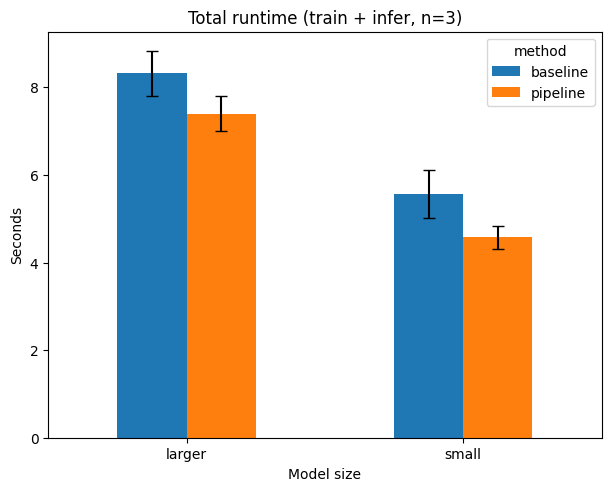

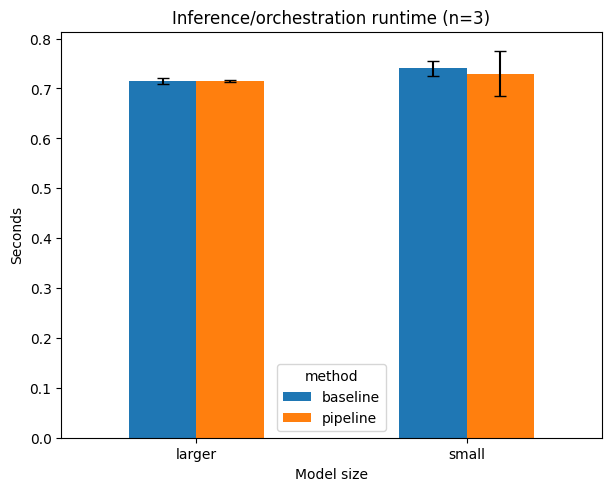

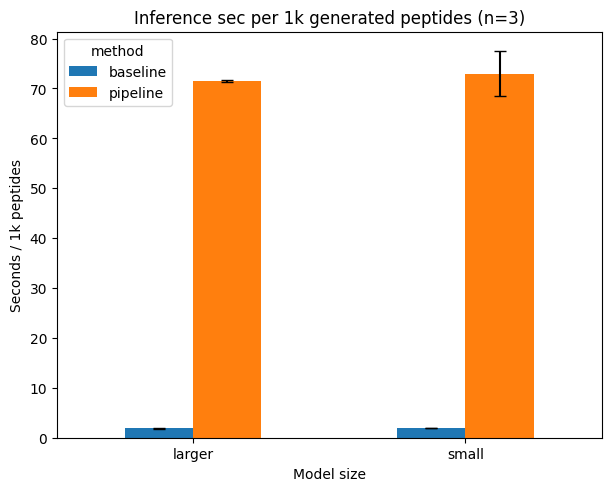

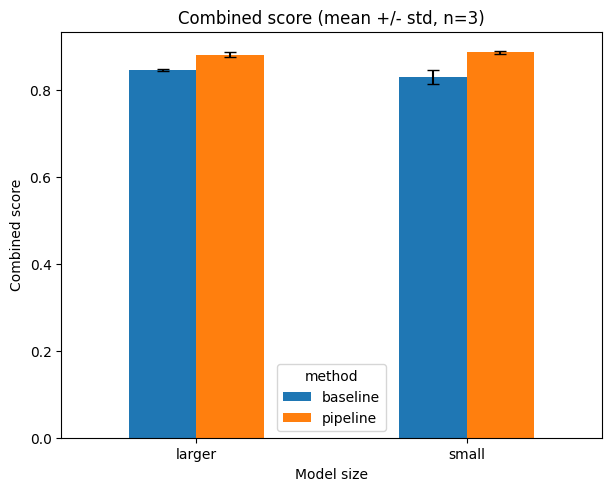

,method,setting,repeat,requested_budget,generated_count,train_sec,infer_sec,runtime_sec,sec_per_1k_generated,infer_sec_per_1k_generated
0,baseline,larger,1,384,384,8.186588,0.720922,8.907510,23.196640,1.877401
1,baseline,larger,2,384,384,7.300368,0.708740,8.009108,20.857053,1.845678
2,baseline,larger,3,384,384,7.312480,0.717275,8.029755,20.910821,1.867903
3,pipeline,larger,1,384,10,6.594750,0.714860,7.309610,730.960995,71.485966
4,pipeline,larger,2,384,10,7.112411,0.715697,7.828108,782.810812,71.569725
5,pipeline,larger,3,384,10,6.343478,0.712381,7.055859,705.585947,71.238107
6,baseline,small,1,384,384,5.346532,0.723788,6.070320,15.808124,1.884864
7,baseline,small,2,384,384,4.882621,0.751782,5.634404,14.672926,1.957767
8,baseline,small,3,384,384,4.224836,0.746796,4.971632,12.946959,1.944781
9,pipeline,small,1,384,10,4.155653,0.690298,4.845951,484.595061,69.029780


In [26]:
import time
import pickle

import matplotlib.pyplot as plt

from baseline.training import train_model
from baseline.inference import generate_peptides

from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.base import BaseBiologist


def sequence_identity(seq, ref):
    if not seq or not ref:
        return 0.0
    n = min(len(seq), len(ref))
    matches = sum(1 for a, b in zip(seq[:n], ref[:n]) if a == b)
    return matches / max(len(ref), 1)


def summarize_identity(sequences, ref):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return {"best_identity": 0.0, "mean_identity": 0.0, "count": 0}
    ids = [sequence_identity(s, ref) for s in clean]
    return {
        "best_identity": float(max(ids)),
        "mean_identity": float(sum(ids) / len(ids)),
        "count": len(clean),
    }


def summarize_agent_scores(scored_rows):
    if not scored_rows:
        return {
            "chemist_mean": 0.0,
            "biologist_mean": 0.0,
            "combined_mean": 0.0,
            "combined_best": 0.0,
            "in_limits_rate": 0.0,
            "scored_count": 0,
        }

    chem = [float(r.get("chemist_score", 0.0)) for r in scored_rows]
    bio = [float(r.get("biologist_score", 0.0)) for r in scored_rows]
    comb = [float(r.get("combined_score", 0.0)) for r in scored_rows]
    in_limits = [1.0 if bool(r.get("in_limits", False)) else 0.0 for r in scored_rows]

    return {
        "chemist_mean": float(np.mean(chem)),
        "biologist_mean": float(np.mean(bio)),
        "combined_mean": float(np.mean(comb)),
        "combined_best": float(np.max(comb)),
        "in_limits_rate": float(np.mean(in_limits)),
        "scored_count": int(len(scored_rows)),
    }


def score_sequences_with_agents(sequences, chemist, biologist):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return []

    chem_rows = chemist.evaluate_peptides(clean)
    valid_rows = [r for r in chem_rows if isinstance(r, dict) and r.get("sequence")]
    peptides = [r["sequence"] for r in valid_rows]

    if not peptides:
        return []

    bio_scores = biologist.score_peptides(peptides)

    rows = []
    for c_row, b_score in zip(valid_rows, bio_scores):
        chem_score = float(c_row.get("score", 0.0))
        bio_score = float(b_score)
        combined = 0.5 * (chem_score + bio_score)
        rows.append(
            {
                "peptide": c_row["sequence"],
                "chemist_score": chem_score,
                "biologist_score": bio_score,
                "combined_score": combined,
                "in_limits": bool(c_row.get("in_limits", False)),
            }
        )
    return rows


class LocalFallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        return [sequence_identity(p, self.reference) for p in peptides]


    def predict_activity(self, peptides, context=None):
        return self.score_peptides(peptides)


def get_biologist(reference_peptide):
    try:
        from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2

        return ESMBiologistGlobalL2(reference_peptide=reference_peptide, batch_size=16, score_temperature=50.0)
    except Exception as e:
        print(f"Using fallback biologist for benchmark: {e}")
        return LocalFallbackBiologist(reference_peptide=reference_peptide)


def build_chemist_from_target(target):
    return ChemistAgent(
        config=ChemistConfig(
            ph=7.0 if target["ph"] is None else float(target["ph"]),
            length=RangeTarget(min=8.0, max=14.0, target=float(target["length"]), weight=1.0),
            molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(target["molecular_weight"]), weight=1.0),
            logp=RangeTarget(min=-3.0, max=3.0, target=float(target["logp"]), weight=1.0),
            net_charge=RangeTarget(min=2.0, max=8.0, target=float(target["net_charge"]), weight=1.0),
            isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(target["isoelectric_point"]), weight=1.0),
            hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(target["hydrophobicity"]), weight=1.0),
        )
    )


def get_pipeline_training_tensors(max_len):
    if all(k in globals() for k in ["pipeline_df", "x", "conditions", "lengths"]):
        return pipeline_df.copy(), x, conditions, lengths

    aa = "ACDEFGHIKLMNPQRSTVWY"
    aa_to_idx = {a: i for i, a in enumerate(aa)}
    pad_idx = 20
    vocab_size = 21

    def encode_one_hot_with_pad_local(sequences, max_len_local):
        out = torch.zeros(len(sequences), max_len_local * vocab_size, dtype=torch.float32)
        for i, seq in enumerate(sequences):
            for pos in range(max_len_local):
                out[i, pos * vocab_size + pad_idx] = 1.0
            for pos, ch in enumerate(seq[:max_len_local]):
                if ch in aa_to_idx:
                    out[i, pos * vocab_size + pad_idx] = 0.0
                    out[i, pos * vocab_size + aa_to_idx[ch]] = 1.0
        return out

    def build_condition_tensor_local(dataframe, model):
        cond_local = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
        cond_local[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
        cond_local[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
        cond_local[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
        cond_local[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
        cond_local[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
        cond_local[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
        cond_local[:, 6] = 0.5
        cond_local[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
        cond_local[:, 8] = 0.0
        cond_local[:, 9] = 5.0
        cond_local[:, 10] = 5.0
        cond_local[:, 11] = 100.0
        return cond_local

    local_loader = JSONDataLoader()
    local_loader.load_data(
        source=str(DATA_PATH),
        columns=[
            "sequence",
            "length",
            "ph",
            "molecular_weight",
            "logp",
            "net_charge",
            "isoelectric_point",
            "hydrophobicity",
            "cathionicity",
        ],
        fillna_defaults={
            "length": 10,
            "ph": 7.0,
            "molecular_weight": 1500.0,
            "logp": 0.0,
            "net_charge": 0.0,
            "isoelectric_point": 7.0,
            "hydrophobicity": 0.0,
            "cathionicity": 0.0,
        },
        normalize_sequence=True,
        sequence_column="sequence",
        keep_standard_amino_acids_only=True,
    )
    df_local = local_loader.get_data().copy()

    cvae_tmp = CVAEGenerator(max_len=max_len, latent_dim=16, hidden_dim=128, condition_dim=32)
    x_local = encode_one_hot_with_pad_local(df_local["sequence"].tolist(), max_len_local=max_len)
    cond_local = build_condition_tensor_local(df_local, cvae_tmp)
    lengths_local = torch.tensor(df_local["length"].astype(int).values, dtype=torch.long)

    return df_local, x_local, cond_local, lengths_local


benchmark_settings = [
    {"label": "small", "epochs": 10, "latent_dim": 16, "hidden_dim": 128},
    {"label": "larger", "epochs": 20, "latent_dim": 32, "hidden_dim": 256},
]

bench_iterations = 8
bench_peptides = 48
bench_top_k = 10
benchmark_repeats = 3

# Fair generation budget: both methods are timed on the same number of requested candidates.
bench_total_budget = int(bench_iterations * bench_peptides)
bench_baseline_samples = bench_total_budget

benchmark_rows = []
ref_sequence = TARGET["sequence"]

pipe_df_local, x_local, cond_local, lengths_local = get_pipeline_training_tensors(SHARED_MAX_LEN)
x_local = x_local.to(torch.float32)
cond_local = cond_local.to(torch.float32)
lengths_local = lengths_local.to(torch.long)

benchmark_biologist = get_biologist(ref_sequence)

for cfg in benchmark_settings:
    label = cfg["label"]
    epochs = int(cfg["epochs"])
    latent_dim = int(cfg["latent_dim"])
    hidden_dim = int(cfg["hidden_dim"])

    for rep in range(1, benchmark_repeats + 1):
        seed_val = SEED + 50_000 + (1000 * (1 if label == "small" else 2)) + rep
        random.seed(seed_val)
        np.random.seed(seed_val)
        torch.manual_seed(seed_val)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed_val)

        chemist_cfg_agent = build_chemist_from_target(TARGET)

        baseline_model_path_cfg = EXPERIMENT_DIR / f"baseline_scale_{label}_rep{rep}_lat{latent_dim}_ep{epochs}.pth"
        baseline_scaler_path_cfg = EXPERIMENT_DIR / f"baseline_scale_{label}_rep{rep}_lat{latent_dim}_ep{epochs}_scaler.pkl"

        # Baseline training time (model fit + scaler loading)
        t0_train = time.perf_counter()
        baseline_model_cfg, _ = train_model(
            dataset_file=str(DATA_PATH),
            scaler_path=str(baseline_scaler_path_cfg),
            batch_size=SHARED_BATCH_SIZE,
            max_len=SHARED_MAX_LEN,
            epochs=epochs,
            latent_dim=latent_dim,
            model_path=str(baseline_model_path_cfg),
        )

        with open(baseline_scaler_path_cfg, "rb") as f:
            baseline_scaler_cfg = pickle.load(f)
        baseline_train_time = float(time.perf_counter() - t0_train)

        baseline_target_cfg = [
            TARGET["length"],
            7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
            TARGET["molecular_weight"],
            TARGET["logp"],
            TARGET["net_charge"],
            TARGET["isoelectric_point"],
            TARGET["hydrophobicity"],
            TARGET["cathionicity"],
        ]

        # Baseline generation/evaluation time only
        t0_infer = time.perf_counter()
        baseline_sequences_cfg = generate_peptides(
            model=baseline_model_cfg,
            scaler=baseline_scaler_cfg,
            num_samples=bench_baseline_samples,
            properties=baseline_target_cfg,
            temperature=0.9,
            top_k=5,
        )
        baseline_scored_rows = score_sequences_with_agents(baseline_sequences_cfg, chemist_cfg_agent, benchmark_biologist)
        baseline_infer_time = float(time.perf_counter() - t0_infer)

        baseline_clean = [s for s in baseline_sequences_cfg if isinstance(s, str) and s]
        baseline_generated = int(len(baseline_clean))
        baseline_total_time = baseline_train_time + baseline_infer_time

        baseline_identity = summarize_identity(baseline_sequences_cfg, ref_sequence)
        baseline_agent_metrics = summarize_agent_scores(baseline_scored_rows)

        benchmark_rows.append(
            {
                "method": "baseline",
                "setting": label,
                "repeat": rep,
                "epochs": epochs,
                "latent_dim": latent_dim,
                "hidden_dim": None,
                "requested_budget": bench_baseline_samples,
                "generated_count": baseline_generated,
                "train_sec": baseline_train_time,
                "infer_sec": baseline_infer_time,
                "runtime_sec": baseline_total_time,
                "sec_per_1k_generated": 1000.0 * baseline_total_time / max(baseline_generated, 1),
                "infer_sec_per_1k_generated": 1000.0 * baseline_infer_time / max(baseline_generated, 1),
                **baseline_identity,
                **baseline_agent_metrics,
            }
        )

        pipeline_model_path_cfg = EXPERIMENT_DIR / f"pipeline_scale_{label}_rep{rep}_lat{latent_dim}_hid{hidden_dim}_ep{epochs}.pth"

        # Pipeline training time
        t1_train = time.perf_counter()
        pipeline_cvae_cfg = CVAEGenerator(
            max_len=SHARED_MAX_LEN,
            latent_dim=latent_dim,
            hidden_dim=hidden_dim,
            condition_dim=32,
        )

        pipeline_cvae_cfg.train_model(
            data=x_local.to(pipeline_cvae_cfg.device),
            conditions=cond_local.to(pipeline_cvae_cfg.device),
            lengths=lengths_local.to(pipeline_cvae_cfg.device),
            epochs=epochs,
            batch_size=SHARED_BATCH_SIZE,
            lr=1e-3,
            kl_anneal_epochs=max(1, epochs // 2),
        )
        pipeline_cvae_cfg.save_model(str(pipeline_model_path_cfg))
        pipeline_train_time = float(time.perf_counter() - t1_train)

        orchestrator_cfg = Orchestrator(
            generator=pipeline_cvae_cfg,
            chemist=chemist_cfg_agent,
            biologist=benchmark_biologist,
        )

        # Pipeline generation/evaluation loop time only
        t1_infer = time.perf_counter()
        pipe_rows_cfg = orchestrator_cfg.run(
            nb_iterations=bench_iterations,
            nb_peptides=bench_peptides,
            top_k=bench_top_k,
            exploration_rate=0.15,
            initial_peptide=ref_sequence,
            final_target={
                "length": TARGET["length"],
                "molecular_weight": TARGET["molecular_weight"],
                "logp": TARGET["logp"],
                "net_charge": TARGET["net_charge"],
                "isoelectric_point": TARGET["isoelectric_point"],
                "hydrophobicity": TARGET["hydrophobicity"],
                "cathionicity": TARGET["cathionicity"],
            },
        )
        pipeline_infer_time = float(time.perf_counter() - t1_infer)

        pipe_sequences_cfg = [r.get("peptide", "") for r in pipe_rows_cfg if isinstance(r, dict)]
        pipeline_generated = int(len([s for s in pipe_sequences_cfg if isinstance(s, str) and s]))
        pipeline_total_time = pipeline_train_time + pipeline_infer_time

        pipeline_identity = summarize_identity(pipe_sequences_cfg, ref_sequence)
        pipeline_scored_rows = [
            {
                "peptide": r.get("peptide", ""),
                "chemist_score": float(r.get("chemist_score", 0.0)),
                "biologist_score": float(r.get("biologist_score", 0.0)),
                "combined_score": float(r.get("combined_score", r.get("score", 0.0))),
                "in_limits": bool(r.get("in_limits", False)),
            }
            for r in pipe_rows_cfg
            if isinstance(r, dict)
        ]
        pipeline_agent_metrics = summarize_agent_scores(pipeline_scored_rows)

        benchmark_rows.append(
            {
                "method": "pipeline",
                "setting": label,
                "repeat": rep,
                "epochs": epochs,
                "latent_dim": latent_dim,
                "hidden_dim": hidden_dim,
                "requested_budget": bench_total_budget,
                "generated_count": pipeline_generated,
                "train_sec": pipeline_train_time,
                "infer_sec": pipeline_infer_time,
                "runtime_sec": pipeline_total_time,
                "sec_per_1k_generated": 1000.0 * pipeline_total_time / max(pipeline_generated, 1),
                "infer_sec_per_1k_generated": 1000.0 * pipeline_infer_time / max(pipeline_generated, 1),
                **pipeline_identity,
                **pipeline_agent_metrics,
            }
        )

benchmark_raw_df = pd.DataFrame(benchmark_rows)
benchmark_summary_df = pd.DataFrame()

if not benchmark_raw_df.empty:
    fixed_df = benchmark_raw_df.copy()
    fixed_df["hidden_dim_group"] = fixed_df["hidden_dim"].fillna(-1).astype(int)

    benchmark_summary_df = fixed_df.groupby(
        ["setting", "method", "epochs", "latent_dim", "hidden_dim_group"],
        as_index=False,
    ).agg(
        requested_budget_mean=("requested_budget", "mean"),
        generated_count_mean=("generated_count", "mean"),
        train_sec_mean=("train_sec", "mean"),
        train_sec_std=("train_sec", "std"),
        infer_sec_mean=("infer_sec", "mean"),
        infer_sec_std=("infer_sec", "std"),
        runtime_sec_mean=("runtime_sec", "mean"),
        runtime_sec_std=("runtime_sec", "std"),
        sec_per_1k_generated_mean=("sec_per_1k_generated", "mean"),
        sec_per_1k_generated_std=("sec_per_1k_generated", "std"),
        infer_sec_per_1k_generated_mean=("infer_sec_per_1k_generated", "mean"),
        infer_sec_per_1k_generated_std=("infer_sec_per_1k_generated", "std"),
        chemist_mean_mean=("chemist_mean", "mean"),
        chemist_mean_std=("chemist_mean", "std"),
        biologist_mean_mean=("biologist_mean", "mean"),
        biologist_mean_std=("biologist_mean", "std"),
        combined_mean_mean=("combined_mean", "mean"),
        combined_mean_std=("combined_mean", "std"),
        combined_best_mean=("combined_best", "mean"),
        combined_best_std=("combined_best", "std"),
        in_limits_rate_mean=("in_limits_rate", "mean"),
        in_limits_rate_std=("in_limits_rate", "std"),
        best_identity_mean=("best_identity", "mean"),
        best_identity_std=("best_identity", "std"),
        mean_identity_mean=("mean_identity", "mean"),
        mean_identity_std=("mean_identity", "std"),
        scored_count_mean=("scored_count", "mean"),
    )

    benchmark_summary_df["hidden_dim"] = benchmark_summary_df["hidden_dim_group"].replace({-1: np.nan})
    benchmark_summary_df = benchmark_summary_df.drop(columns=["hidden_dim_group"])
    benchmark_summary_df = benchmark_summary_df.sort_values(["setting", "method"]).reset_index(drop=True)

display(benchmark_summary_df)
display(benchmark_raw_df.head(8))

if not benchmark_summary_df.empty:
    total_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="runtime_sec_mean")
    total_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="runtime_sec_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    total_pivot.plot(kind="bar", yerr=total_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Total runtime (train + infer, n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds")
    plt.show()

    infer_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_mean")
    infer_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    infer_pivot.plot(kind="bar", yerr=infer_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Inference/orchestration runtime (n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds")
    plt.show()

    norm_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_per_1k_generated_mean")
    norm_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_per_1k_generated_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    norm_pivot.plot(kind="bar", yerr=norm_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Inference sec per 1k generated peptides (n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds / 1k peptides")
    plt.show()

    quality_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="combined_mean_mean")
    quality_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="combined_mean_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    quality_pivot.plot(kind="bar", yerr=quality_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Combined score (mean +/- std, n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Combined score")
    plt.show()

runtime_check_df = pd.DataFrame()
if not benchmark_raw_df.empty:
    runtime_check_df = benchmark_raw_df[
        [
            "method",
            "setting",
            "repeat",
            "requested_budget",
            "generated_count",
            "train_sec",
            "infer_sec",
            "runtime_sec",
            "sec_per_1k_generated",
            "infer_sec_per_1k_generated",
        ]
    ].sort_values(["setting", "method", "repeat"]).reset_index(drop=True)
    display(runtime_check_df)


In [22]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()